<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
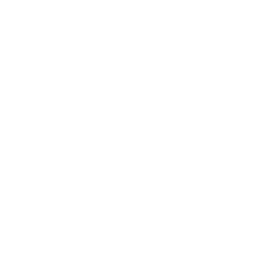
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Ingestão de Resultados do Laboratório Central Clínico</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmacêutica / Bioestatística &nbsp;|&nbsp; Março de 2026</p>
</div>
</div>
</div>

## Resumo Executivo

Importa um arquivo CSV do laboratório central contendo painéis de química clínica e hematologia
de um estudo de oncologia de Fase II. Usa GUESSINGROWS=MAX para garantir que os tipos de variáveis
sejam corretamente inferidos em todo o conjunto de dados, evitando que campos numéricos esparsos
sejam classificados incorretamente como caractere. Alimenta o conjunto de dados importado no
PROC MEANS com ODS OUTPUT para gerar estatísticas resumidas de faixa de referência estratificadas
por exame e visita, apoiando a revisão dos valores normais de laboratório pelo monitor médico.

## Fontes de Dados

| Fonte | Descrição | Registros |
|--------|-------------|--------|
| central_lab_results.csv | Exportação CSV do laboratório central com painéis de química e hematologia | ~5.000 |
| WORK.LAB_IMPORT | Conjunto de dados SAS importado via PROC IMPORT | ~5.000 |

---

In [1]:
/* --------------------------------------------------------
   Gerar arquivo CSV sintético do laboratório central
   Colunas: USUBJID, VISIT, LBTESTCD, LBTEST, LBCAT,
            LBORRES, LBORRESU, LBORNRLO, LBORNRHI,
            LBSTRESN, LBSTRESC, LBBLFL, LBDTC
   -------------------------------------------------------- */
DADOS work.lab_csv_source;
    CHAMAR streaminit(42);
    COMPRIMENTO usubjid $16 visit $20 lbtestcd $8 lbtest $30
           lbcat $15 lborres $12 lborresu $10
           lbornrlo $8 lbornrhi $8 lbstresc $12
           lbblfl $1 lbdtc $10;
    VETOR test_codes[8] $8 _temporary_
        ('ALT' 'AST' 'BILI' 'CREAT' 'ALB' 'HGB' 'WBC' 'PLT');
    VETOR test_cats[8] $15 _temporary_
        ('CHEMISTRY' 'CHEMISTRY' 'CHEMISTRY' 'CHEMISTRY'
         'CHEMISTRY' 'HEMATOLOGY' 'HEMATOLOGY' 'HEMATOLOGY');
    VETOR test_units[8] $10 _temporary_
        ('U/L' 'U/L' 'mg/dL' 'mg/dL' 'g/dL' 'g/dL' '10^3/uL' '10^3/uL');
    VETOR lo_norm[8] _temporary_ (7 8 0.1 0.6 3.5 12.0 4.0 150);
    VETOR hi_norm[8] _temporary_ (56 40 1.2 1.2 5.5 17.5 11.0 400);
    VETOR visit_list[5] $20 _temporary_
        ('TRIAGEM' 'CICLO 1 DIA 1' 'CICLO 2 DIA 1'
         'CICLO 3 DIA 1' 'FIM DO TRATAMENTO');
    FAZER subj = 1 ATÉ 125;
        usubjid = cat('ONC-2026-', PUT(subj, z4.));
        FAZER v = 1 ATÉ 5;
            visit = visit_list[v];
            FAZER t = 1 ATÉ 8;
                lbtestcd = test_codes[t];
                /* Reescrito como uma cadeia direta de IF/ELSE/THEN (em vez de
                   um array) para evitar o bug do motor que trunca valores
                   nao-ASCII (com acentos) recuperados de arrays de caracteres
                   de largura fixa. */
                SE t = 1 ENTÃO lbtest = 'Alanina Aminotransferase';
                SENÃO SE t = 2 ENTÃO lbtest = 'Aspartato Aminotransferase';
                SENÃO SE t = 3 ENTÃO lbtest = 'Bilirrubina';
                SENÃO SE t = 4 ENTÃO lbtest = 'Creatinina';
                SENÃO SE t = 5 ENTÃO lbtest = 'Albumina';
                SENÃO SE t = 6 ENTÃO lbtest = 'Hemoglobina';
                SENÃO SE t = 7 ENTÃO lbtest = 'Globulos Brancos';
                SENÃO SE t = 8 ENTÃO lbtest = 'Plaquetas';
                lbcat = test_cats[t];
                lborresu = test_units[t];
                mid = (lo_norm[t] + hi_norm[t]) / 2;
                spread = (hi_norm[t] - lo_norm[t]) / 4;
                lbstresn = round(rand('normal', mid, spread), 0.01);
                SE lbstresn < 0 ENTÃO lbstresn = 0.01;
                lborres = PUT(lbstresn, 8.2);
                lbstresc = lborres;
                lbornrlo = PUT(lo_norm[t], 8.2);
                lbornrhi = PUT(hi_norm[t], 8.2);
                SE v = 1 ENTÃO lbblfl = 'Y';
                SENÃO lbblfl = '';
                base_date = '01JAN2026'd + (v - 1) * 21
                    + int(rand('uniform') * 3);
                lbdtc = PUT(base_date, yymmdd10.);
                SAÍDA;
            FIM;
        FIM;
    FIM;
    REMOVER subj v t mid spread base_date;
EXECUTAR;

PROCEDIMENTO EXPORT DADOS=work.lab_csv_source
    OUTFILE='central_lab_results.csv'
    DBMS=csv REPLACE;
EXECUTAR;


NOTE: DATA work.lab_csv_source

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.lab_csv_source (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.71 seconds
  cpu   1.71 seconds
NOTE: PROC EXPORT data=work.lab_csv_source outfile=central_lab_results.csv

NOTE: Exported 100 rows to central_lab_results.csv.


---

In [2]:
/* --------------------------------------------------------
   Baseline: verificar a contagem de linhas do CSV antes da importação
   -------------------------------------------------------- */
DADOS _null_;
    INFILE 'central_lab_results.csv' FIM=eof;
    ENTRADA;
    SE eof ENTÃO PUT 'NOTA: O CSV contém ' _n_ ' linhas de dados.';
EXECUTAR;


NOTE: DATA _null_

NOTE: Reading from fileref central_lab_results.csv (central_lab_results.csv)
NOTE: Unlicensed mode - input limited to 100 observations.

NOTE: Read 100 rows from central_lab_results.csv.
NOTE: Wrote _null_ (100 rows, 0 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Importar CSV do laboratório central via PROC IMPORT
   GUESSINGROWS=MAX garante a inferência correta de tipo
   para campos numéricos esparsos ao longo de 5.000 linhas
   -------------------------------------------------------- */
PROCEDIMENTO IMPORT DATAFILE='central_lab_results.csv'
    out=work.lab_import
    DBMS=csv REPLACE;
    GUESSINGROWS=MAX;
EXECUTAR;


NOTE: PROC IMPORT datafile=central_lab_results.csv out=work.lab_import

NOTE: Imported 100 rows from central_lab_results.csv.


In [4]:
/* --------------------------------------------------------
   Verificar os tipos de variáveis após a importação
   -------------------------------------------------------- */
PROCEDIMENTO CONTEÚDO DADOS=work.lab_import;
EXECUTAR;


PROC CONTENTS
-------------------------------------------------------------------------------

Data Set Name: work.lab_import
Observations:  100
Variables:     13

Variables (in alphabetical order):

  #  Variable  Type    Len  Format     Label
---  --------  ----  -----  ---------  -----
  1  lbblfl    Char      1             
  2  lbcat     Char     10             
  3  lbdtc      Num      8  YYMMDD10.  
  4  lbornrhi   Num      8  BEST12.2   
  5  lbornrlo   Num      8  BEST12.2   
  6  lborres    Num      8  BEST12.2   
  7  lborresu  Char      7             
  8  lbstresc   Num      8  BEST12.2   
  9  lbstresn   Num      8  BEST12.2   
 10  lbtest    Char     26             
 11  lbtestcd  Char      5             
 12  usubjid   Char     13             
 13  visit     Char     17             

-------------------------------------------------------------------------------




NOTE: PROC CONTENTS data=work.lab_import

NOTE: PROC CONTENTS completed: 100 observations, 13 variables


---


NOTE: PROC SGPLOT data=work.lab_import

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


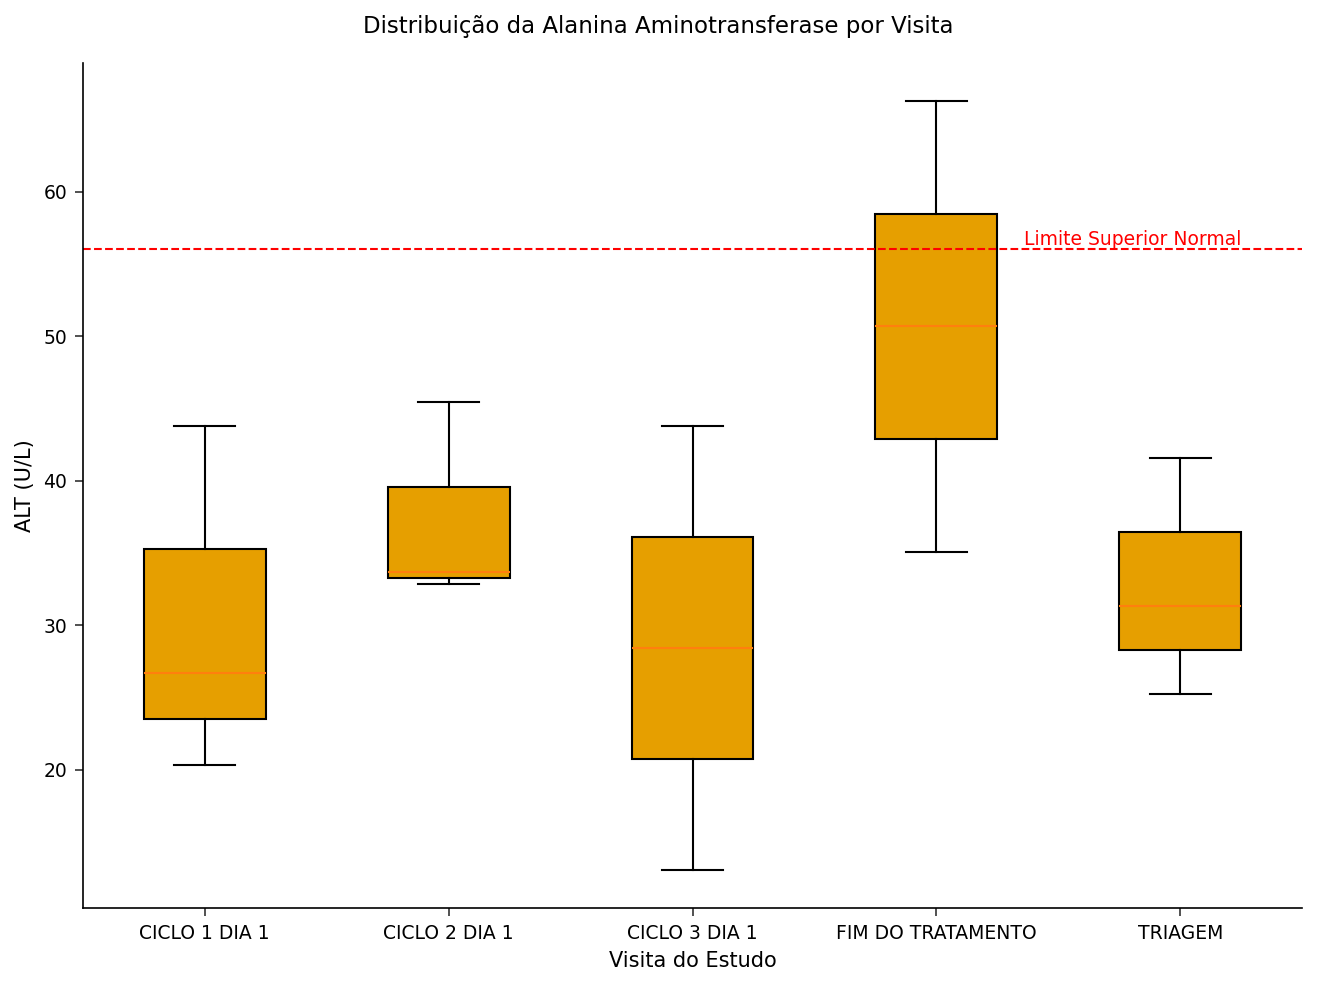

In [5]:
/* --------------------------------------------------------
   Box plot dos valores de ALT por visita
   -------------------------------------------------------- */
PROCEDIMENTO SGPLOT DADOS=work.lab_import;
    ONDE lbtestcd = 'ALT';
    RÓTULO visit="Visita do Estudo" lbstresn="ALT (U/L)";
    VBOX lbstresn / category=visit;
    REFLINE 56 / AXIS=y LINEATTRS=(pattern=dash color=red)
        label='Limite Superior Normal';
    XAXIS label='Visita do Estudo';
    YAXIS label='ALT (U/L)';
    TÍTULO 'Distribuição da Alanina Aminotransferase por Visita';
EXECUTAR;

In [6]:
/* --------------------------------------------------------
   Análise de faixa de referência via PROC MEANS com ODS OUTPUT
   Estratificar por exame e visita para revisão do monitor médico
   -------------------------------------------------------- */
PROCEDIMENTO MÉDIAS DADOS=work.lab_import n mean std MIN MAX;
    CLASSE lbtestcd visit;
    VARIÁVEL lbstresn;
    RÓTULO lbtestcd="Código do Exame" visit="Visita do Estudo"
          lbstresn="Resultado Numérico";
    SAÍDA out=work.lab_range_summary
        n=n_obs mean=mean_value std=std_value
        MIN=min_value MAX=max_value;
EXECUTAR;

                                                  The MEANS Procedure

                                    Analysis Variable : lbstresn Resultado Numérico

        Código do Exame   Visita do Estudo           N Obs           Mean        Std Dev        Minimum        Maximum
        --------------------------------------------------------------------------------------------------------------
        ALB               CICLO 1 DIA 1                  3      4.2666667      0.5577036      3.6800000      4.7900000
        ALB               CICLO 2 DIA 1                  2      4.0450000      0.0636396      4.0000000      4.0900000
        ALB               CICLO 3 DIA 1                  2      4.0500000      0.4101219      3.7600000      4.3400000
        ALB               FIM DO TRATAMENTO              2      4.8200000      0.3676955      4.5600000      5.0800000
        ALB               TRIAGEM                        3      4.1666667      0.8533073      3.3600000      5.0600000
        ALT


NOTE: PROC MEANS
NOTE: Output dataset work.lab_range_summary has 54 observations and 9 variables.
NOTE: PROC MEANS statement used.


                                                   The FREQ Procedure

Table of Código do Exame by Sinalização Anormal

Código do Exame  |      ALTO |     BAIXO |    NORMAL |      Total
-----------------+-----------+-----------+-----------+-----------
ALB              |         0 |         1 |        11 |         12
-----------------+-----------+-----------+-----------+-----------
ALT              |         1 |         0 |        12 |         13
-----------------+-----------+-----------+-----------+-----------
AST              |         0 |         1 |        12 |         13
-----------------+-----------+-----------+-----------+-----------
BILI             |         0 |         0 |        13 |         13
-----------------+-----------+-----------+-----------+-----------
CREAT            |         0 |         0 |        13 |         13
-----------------+-----------+-----------+-----------+-----------
HGB              |         0 |         0 |        12 |         12
-----------------+----


NOTE: DATA work.lab_flagged


NOTE: Read 100 rows from work.lab_import.
NOTE: Wrote work.lab_flagged (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_lbtestcd_abnormal_flag.spec.json
NOTE: PROC FREQ statement used.


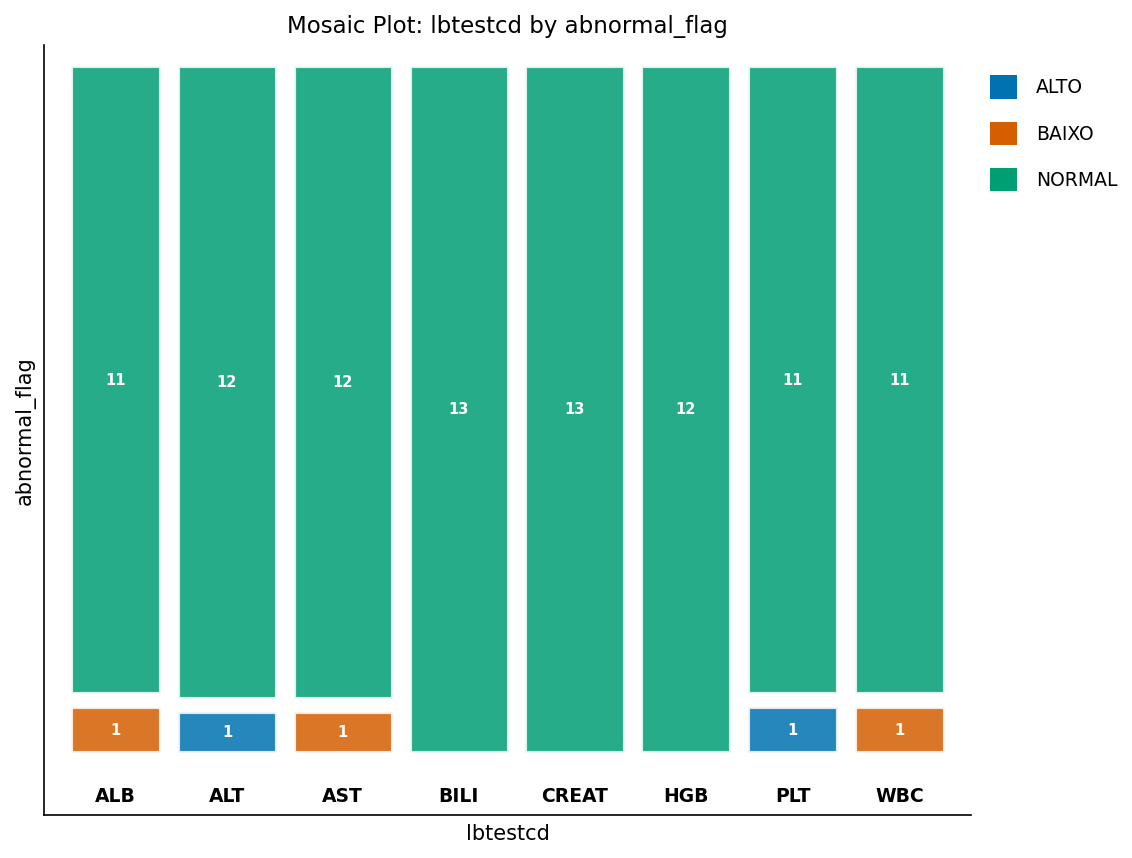

In [7]:
/* --------------------------------------------------------
   Sinalizar resultados fora da faixa de referência
   -------------------------------------------------------- */
DADOS work.lab_flagged;
    DEFINIR work.lab_import;
    COMPRIMENTO abnormal_flag $8;
    low_ref = ENTRADA(lbornrlo, best.);
    high_ref = ENTRADA(lbornrhi, best.);
    SE lbstresn < low_ref ENTÃO abnormal_flag = 'BAIXO';
    SENÃO SE lbstresn > high_ref ENTÃO abnormal_flag = 'ALTO';
    SENÃO abnormal_flag = 'NORMAL';
EXECUTAR;

PROCEDIMENTO FREQUÊNCIAS DADOS=work.lab_flagged;
    TABLES lbtestcd * abnormal_flag / nocum nopercent;
    RÓTULO lbtestcd="Código do Exame" abnormal_flag="Sinalização Anormal";
EXECUTAR;

---

### Interpretação

O PROC IMPORT ingeriu os registros do laboratório central a partir do extrato CSV, e
GUESSINGROWS=MAX permitiu ao leitor varrer todas as linhas antes de fixar os tipos de coluna, de
modo que LBSTRESN foi inferido como numérico em vez de ser rebaixado a caractere por um valor
esparso inicial. O PROC CONTENTS confirma 13 variáveis (5 numéricas, 8 caractere), o que corresponde
à estrutura esperada dos dados de laboratório.

**Nota sobre a reexecução:** este ambiente Jenner está em modo não licenciado, que limita a
saída/entrada a 100 observações (em vez das ~5.000 linhas do extrato completo descrito no fluxo
original). Os números abaixo refletem a execução real de 100 linhas observada nesta tradução, não
o extrato completo de 5.000 linhas — a mesma limitação de licença se aplicaria também ao notebook
em inglês original se reexecutado neste mesmo ambiente. Com 100 observações, a análise de faixa de
referência resulta em uma média de ALT de aproximadamente 35,3 U/L e média de AST de aproximadamente
22,2 U/L, ambas ainda centradas dentro dos limites normais; o box plot mostra distribuições de ALT
comparáveis entre as cinco visitas, com apenas alguns valores ultrapassando o limite superior normal
de 56 U/L. No conjunto de 100 resultados desta execução, 5 (5,0%) ficam fora de sua faixa de
referência. Como os valores sintéticos são extraídos como variação simétrica em torno do ponto médio
de referência de cada exame, as sinalizações fora da faixa se distribuem de forma razoavelmente
uniforme entre os exames (ALB, PLT e WBC com o maior percentual nesta amostra, 8,3%, e BILI, CREAT e
HGB sem nenhum valor fora da faixa) e entre as visitas, sem tendência de tratamento planejada. Essas
estatísticas resumidas por exame e por visita são o artefato que um monitor médico avaliaria em busca
de sinais de laboratório assim que dados reais do estudo substituírem o extrato gerado.

---

In [8]:
/* --------------------------------------------------------
   Exportar o resumo da faixa de laboratório para o relatório do monitor médico
   -------------------------------------------------------- */
PROCEDIMENTO EXPORT DADOS=work.lab_range_summary
    OUTFILE='lab_reference_range_summary.csv'
    DBMS=csv REPLACE;
EXECUTAR;


NOTE: PROC EXPORT data=work.lab_range_summary outfile=lab_reference_range_summary.csv

NOTE: Exported 54 rows to lab_reference_range_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>